# EDA 01: Contact reasons and complaint categories

**Goal:** ground the workflow choice of the proposal ([10_proposal.md](../../docs/strategy_analysis_01/10_proposal.md)): *transaction-dispute intake, "I don't recognize this charge"*.

**Questions**
1. Which contact reasons drive the most volume and agent time?
2. Where does service fail: low first-contact resolution, escalation, follow-ups, negative sentiment?
3. How big is the "unrecognized charge" problem in the complaints system, and how is it handled (SLA, amounts, status)?
4. What are the data-quality caveats of this synthetic dataset?

**Data:** `data/bronze/call_center_interactions.parquet`, `data/bronze/complaints.parquet`, `data/bronze/customers.parquet` (organizer-provided, fully synthetic). Run `make data-lite && make bronze` first.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
BRONZE = ROOT / "data" / "bronze"

con = duckdb.connect()
con.sql(f"CREATE VIEW interactions AS SELECT * FROM '{BRONZE / 'call_center_interactions.parquet'}'")
con.sql(f"CREATE VIEW complaints AS SELECT * FROM '{BRONZE / 'complaints.parquet'}'")
con.sql(f"CREATE VIEW customers AS SELECT * FROM '{BRONZE / 'customers.parquet'}'")

# Reference categorical palette (fixed order, never cycled); text never wears series color.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, SURFACE = "#0b0b0b", "#898781", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "font.size": 10, "figure.dpi": 110,
})
q = lambda sql: con.sql(sql).df()

## 1. Data overview

In [2]:
q('''
SELECT count(*) AS interactions, count(DISTINCT interaction_id) AS unique_ids,
       count(DISTINCT customer_id) AS customers,
       min(interaction_date)::DATE AS first_day, max(interaction_date)::DATE AS last_day,
       count(DISTINCT contact_reason) AS contact_reasons, count(DISTINCT reason_category) AS reason_categories,
       avg((contact_reason = reason_category)::INT) AS reason_equals_category
FROM interactions
''')

,interactions,unique_ids,customers,first_day,last_day,contact_reasons,reason_categories,reason_equals_category
0,686296,686296,148443,2023-06-17,2026-06-18,6,6,1.0


> `contact_reason` and `reason_category` carry the same values, so the dataset gives **6 coarse reasons**, not fine-grained intents such as "unrecognized charge". The fine-grained signal is in `complaints.subcategory` (section 4).

## 2. Volume and agent time by reason category

In [3]:
kpi = q('''
SELECT reason_category,
       count(*) AS interactions,
       count(*) / sum(count(*)) OVER () AS share,
       sum(duration_seconds) / 3600 AS agent_hours,
       sum(duration_seconds) / sum(sum(duration_seconds)) OVER () AS agent_time_share,
       avg(duration_seconds) / 60 AS avg_duration_min,
       avg(wait_time_seconds) / 60 AS avg_wait_min,
       avg(was_resolved::INT) AS fcr,
       avg(was_escalated::INT) AS escalation_rate,
       avg(requires_followup::INT) AS followup_rate,
       avg((detected_sentiment IN ('Negativo', 'Muy Negativo'))::INT) AS negative_sentiment
FROM interactions
GROUP BY 1
ORDER BY interactions DESC
''')
kpi.style.format({c: "{:.1%}" for c in ["share", "agent_time_share", "fcr", "escalation_rate",
                                        "followup_rate", "negative_sentiment"]}
                 | {"interactions": "{:,.0f}", "agent_hours": "{:,.0f}",
                    "avg_duration_min": "{:.1f}", "avg_wait_min": "{:.1f}"})

,reason_category,interactions,share,agent_hours,agent_time_share,avg_duration_min,avg_wait_min,fcr,escalation_rate,followup_rate,negative_sentiment
0,Transaccional,"240,056",35.0%,"12,663",24.0%,3.7,2.0,91.5%,9.9%,22.1%,0.0%
1,Producto,"150,863",22.0%,"9,593",18.2%,4.4,2.0,89.6%,10.0%,23.8%,19.2%
2,Queja,"117,021",17.1%,"12,160",23.1%,7.2,2.0,43.6%,10.0%,63.0%,34.9%
3,Técnico,"102,899",15.0%,"8,861",16.8%,6.0,2.0,69.9%,10.1%,40.6%,35.0%
4,Comercial,"54,879",8.0%,"7,061",13.4%,9.0,2.0,65.2%,9.8%,44.5%,34.9%
5,Retención,"20,578",3.0%,"2,350",4.5%,8.0,2.0,60.2%,9.8%,49.1%,34.9%


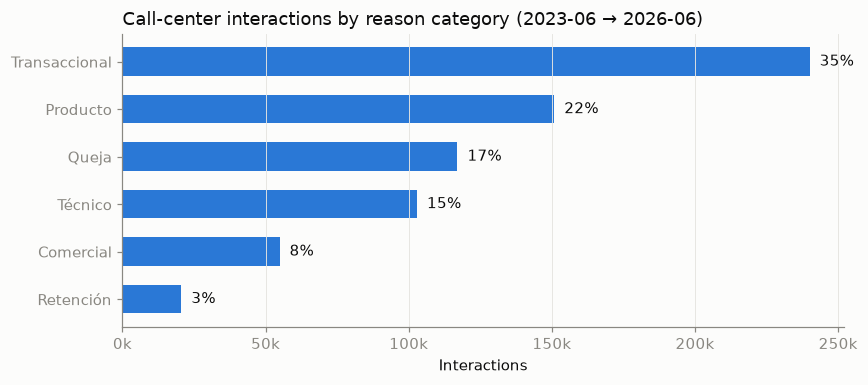

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
d = kpi.sort_values("interactions")
bars = ax.barh(d["reason_category"], d["interactions"], color=PALETTE[0], height=0.6)
for b, s in zip(bars, d["share"]):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f"  {s:.0%}", va="center", color=INK)
ax.set_title("Call-center interactions by reason category (2023-06 → 2026-06)", loc="left")
ax.set_xlabel("Interactions"); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(lambda x, _: f"{x/1e3:.0f}k")
plt.tight_layout(); plt.show()

## 3. Where service fails, by reason category
One panel per metric (no dual axes); same category order in every panel.

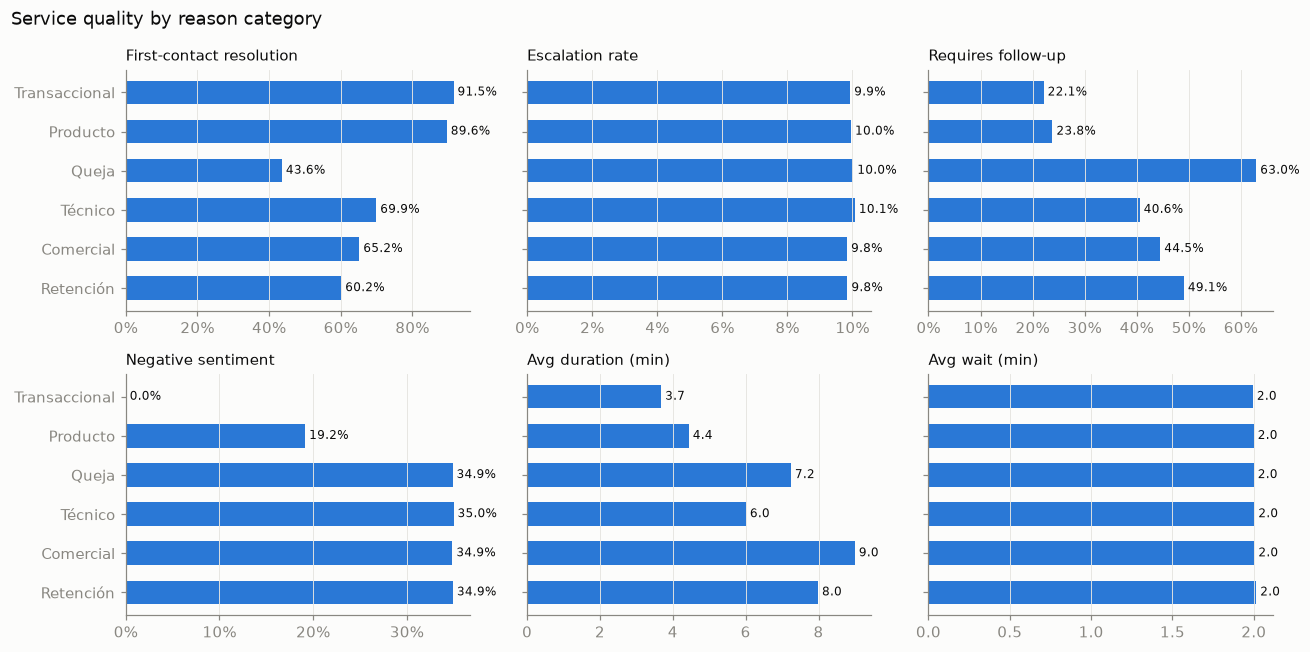

In [5]:
metrics = [("fcr", "First-contact resolution"), ("escalation_rate", "Escalation rate"),
           ("followup_rate", "Requires follow-up"), ("negative_sentiment", "Negative sentiment"),
           ("avg_duration_min", "Avg duration (min)"), ("avg_wait_min", "Avg wait (min)")]
order = kpi.sort_values("interactions", ascending=False)["reason_category"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, (col, title) in zip(axes.flat, metrics):
    d = kpi.set_index("reason_category").loc[order[::-1], col]
    ax.barh(d.index, d.values, color=PALETTE[0], height=0.6)
    for y, v in enumerate(d.values):
        ax.text(v, y, f" {v:.1%}" if v <= 1 else f" {v:.1f}", va="center", fontsize=8, color=INK)
    ax.set_title(title, loc="left", fontsize=10); ax.grid(axis="y", visible=False)
    if d.max() <= 1:
        ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.suptitle("Service quality by reason category", x=0.01, ha="left")
plt.tight_layout(); plt.show()

## 4. Trend over time
Monthly volume per category, to check whether demand is stable (seasonality or growth would matter for capacity).

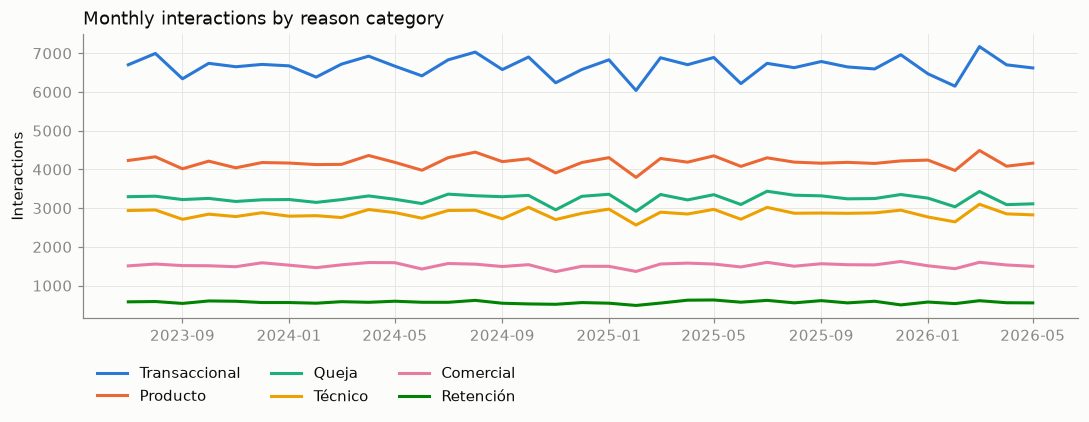

In [6]:
monthly = q('''
SELECT date_trunc('month', interaction_date) AS month, reason_category, count(*) AS n
FROM interactions GROUP BY ALL ORDER BY 1
''').pivot(index="month", columns="reason_category", values="n")[order]
monthly = monthly.iloc[1:-1]  # drop partial first/last months
fig, ax = plt.subplots(figsize=(10, 4))
for i, cat in enumerate(order):
    ax.plot(monthly.index, monthly[cat], color=PALETTE[i], linewidth=2, label=cat)
ax.set_title("Monthly interactions by reason category", loc="left"); ax.set_ylabel("Interactions")
ax.legend(ncol=3, frameon=False, loc="upper left", bbox_to_anchor=(0, -0.12))
plt.tight_layout(); plt.show()

## 5. Reason mix by country and channel

In [7]:
by_country = q('''
SELECT c.country, i.reason_category, count(*) AS n
FROM interactions i LEFT JOIN customers c USING (customer_id)
GROUP BY ALL
''').pivot(index="reason_category", columns="country", values="n").loc[order]
(by_country / by_country.sum()).style.format("{:.1%}").set_caption("Share of each country's interactions")

country,Argentina,Colombia,México
reason_category,,,
Transaccional,35.0%,35.1%,34.9%
Producto,22.0%,22.0%,22.0%
Queja,17.2%,17.0%,17.0%
Técnico,15.0%,14.9%,15.1%
Comercial,7.9%,8.0%,8.1%
Retención,3.0%,3.0%,3.0%


In [8]:
by_channel = q('''
SELECT channel, reason_category, count(*) AS n FROM interactions GROUP BY ALL
''').pivot(index="reason_category", columns="channel", values="n").loc[order]
(by_channel / by_channel.sum()).style.format("{:.1%}").set_caption("Share of each channel's interactions")

channel,App,Email,Phone,Web,Web Chat,WhatsApp
reason_category,,,,,,
Transaccional,35.2%,34.8%,35.0%,35.0%,35.0%,34.8%
Producto,22.3%,22.1%,22.0%,20.6%,21.8%,21.8%
Queja,16.7%,16.8%,17.1%,17.3%,17.3%,17.0%
Técnico,14.9%,15.1%,15.0%,15.6%,14.6%,15.2%
Comercial,8.0%,7.9%,8.0%,8.2%,8.3%,8.2%
Retención,3.0%,3.2%,3.0%,3.2%,3.0%,3.1%


## 6. Complaints: how big is "unrecognized charge"?
The complaints (PQR) table has the fine-grained subcategory the interactions lack.

In [9]:
comp = q('''
SELECT category, subcategory, count(*) AS complaints,
       count(*) / sum(count(*)) OVER () AS share,
       avg(sla_breached::INT) AS sla_breach_rate,
       avg(resolution_days) AS avg_resolution_days,
       count(claimed_amount) AS with_amount,
       median(claimed_amount) AS median_claimed_amount,
       avg((status IN ('Open', 'In Process', 'Escalated'))::INT) AS still_open_share
FROM complaints GROUP BY ALL ORDER BY complaints DESC
''')
comp.style.format({"share": "{:.1%}", "sla_breach_rate": "{:.1%}", "still_open_share": "{:.1%}",
                   "avg_resolution_days": "{:.1f}", "median_claimed_amount": "{:,.0f}",
                   "complaints": "{:,.0f}", "with_amount": "{:,.0f}"})

,category,subcategory,complaints,share,sla_breach_rate,avg_resolution_days,with_amount,median_claimed_amount,still_open_share
0,Transactions,Cargo no reconocido,"12,297",18.3%,20.4%,15.4,"4,090","2,524",74.6%
1,Fees,Cobro indebido,"12,194",18.2%,19.9%,15.6,"4,035","2,514",75.3%
2,Technical,Problema con app,"12,128",18.1%,20.0%,15.5,"3,923","2,517",75.1%
3,Branch,Atención en sucursal,"11,892",17.7%,20.4%,15.6,"3,735","2,675",74.9%
4,Service,Calidad de servicio,"11,886",17.7%,20.3%,15.9,"3,816","2,518",75.1%
5,Branch,nan,"1,469",2.2%,20.6%,15.4,488,"2,455",73.2%
6,Fees,nan,"1,359",2.0%,18.3%,15.2,422,"2,483",74.8%
7,Service,nan,"1,308",1.9%,19.8%,15.8,403,"2,401",74.8%
8,Transactions,nan,"1,283",1.9%,18.1%,16.0,410,"2,500",74.2%
9,Technical,nan,"1,279",1.9%,19.7%,16.0,429,"2,392",74.7%


In [10]:
disputes = q('''
SELECT count(*) AS unrecognized_charge_complaints,
       count(DISTINCT customer_id) AS customers,
       avg(is_repeat_complainer::INT) AS repeat_complainer_share,
       avg((status IN ('Open', 'In Process', 'Escalated'))::INT) AS still_open_share,
       avg(sla_breached::INT) AS sla_breach_rate,
       avg(resolution_days) AS avg_resolution_days
FROM complaints WHERE subcategory = 'Cargo no reconocido'
''')
disputes

,unrecognized_charge_complaints,customers,repeat_complainer_share,still_open_share,sla_breach_rate,avg_resolution_days
0,12297,11818,0.146946,0.745873,0.203871,15.357442


In [11]:
# Claimed amounts are in mixed currencies: never sum across them.
q('''
SELECT coalesce(currency, 'missing') AS currency, count(*) AS complaints_with_amount,
       median(claimed_amount) AS median_claimed, sum(claimed_amount) AS total_claimed
FROM complaints WHERE subcategory = 'Cargo no reconocido' AND claimed_amount IS NOT NULL
GROUP BY 1 ORDER BY 2 DESC
''')

,currency,complaints_with_amount,median_claimed,total_claimed
0,MXN,989,2678.790,2561344.86
1,USD,985,2552.700,2534851.32
2,COP,977,2397.960,2389318.16
3,ARS,956,2502.505,2411564.08
4,missing,183,2731.380,482659.04


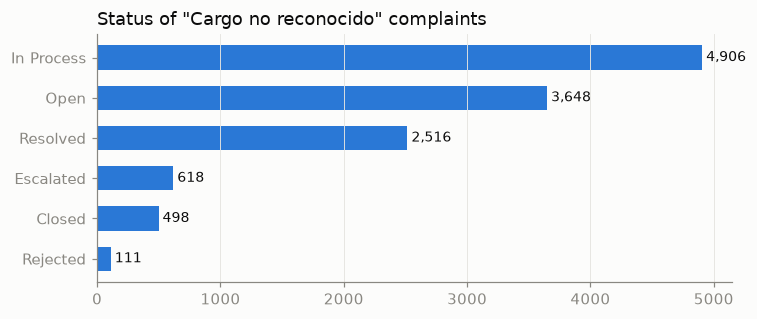

In [12]:
status = q('''
SELECT status, count(*) AS n FROM complaints WHERE subcategory = 'Cargo no reconocido'
GROUP BY 1 ORDER BY 2 DESC
''')
fig, ax = plt.subplots(figsize=(7, 3))
d = status.sort_values("n")
ax.barh(d["status"], d["n"], color=PALETTE[0], height=0.6)
for y, v in enumerate(d["n"]):
    ax.text(v, y, f" {v:,}", va="center", color=INK, fontsize=9)
ax.set_title('Status of "Cargo no reconocido" complaints', loc="left"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 7. Data-quality caveats (synthetic data)

In [13]:
checks = {
    "interactions: rows vs. ~800k in the dictionary": q("SELECT count(*) FROM interactions").iat[0, 0],
    "complaints: rows vs. ~80k in the dictionary": q("SELECT count(*) FROM complaints").iat[0, 0],
    "complaints: distinct description texts": q("SELECT count(DISTINCT description) FROM complaints").iat[0, 0],
    "complaints: distinct resolution texts": q("SELECT count(DISTINCT resolution) FROM complaints").iat[0, 0],
    "complaints: origin_interaction_id filled": q("SELECT count(origin_interaction_id) FROM complaints").iat[0, 0],
    "complaints: SLA-breach rate spread across categories (max - min)":
        round(comp["sla_breach_rate"].max() - comp["sla_breach_rate"].min(), 4),
    "interactions: escalation-rate spread across categories (max - min)":
        round(kpi["escalation_rate"].max() - kpi["escalation_rate"].min(), 4),
}
pd.Series(checks, name="value").to_frame()

,value
interactions: rows vs. ~800k in the dictionary,686296.0000
complaints: rows vs. ~80k in the dictionary,67095.0000
complaints: distinct description texts,5.0000
complaints: distinct resolution texts,5.0000
complaints: origin_interaction_id filled,0.0000
complaints: SLA-breach rate spread across categories (max - min),0.0254
interactions: escalation-rate spread across categories (max - min),0.0024


## 8. Findings and decision

**What the data says** (686,296 interactions and 67,095 complaints, 2023-06 → 2026-06; all synthetic):

| Signal | Evidence | Implication for the proposal |
|---|---|---|
| **Volume** | *Transaccional* is the #1 reason: **35.0%** of interactions (240k) and **24.0%** of agent time | Transaction-related contacts are where automation saves the most capacity |
| **Where service fails** | *Queja* has the worst outcomes: **43.6%** FCR, **63.0%** needing follow-up, 7.2 min per call, 23.1% of agent time | Complaints are expensive and rarely solved on first contact |
| **The intersection** | *Cargo no reconocido* is **12,297 complaints (18.3% of all complaints)** from 11,818 customers; **74.6%** are still Open / In Process / Escalated; SLA breached in **20.4%**; ~15.4 days to resolve | "I don't recognize this charge" starts as a transactional contact and ends as a slow, unresolved complaint. **This is the gap RASTRO targets:** resolve it at the first contact, before it becomes a complaint |
| **Stability** | The reason mix is the same across countries (≈35% transactional in MX, CO, and AR) and across channels | One workflow serves all three markets; no country-specific product is needed |

**Decision:** the data supports **transaction-dispute intake ("unrecognized charge")** as the single workflow. It sits at the intersection of the highest-volume reason (transactional) and the worst-performing outcome (complaints).

**Data-quality caveats to report honestly:**
- Row counts are below the dictionary: 686k interactions vs ~800k, and 67k complaints vs ~80k.
- `contact_reason` equals `reason_category`: only 6 coarse reasons.
- Complaint `description` and `resolution` have only 5 template texts each, and `origin_interaction_id` is always empty, so complaints can't be linked to calls.
- Several metrics look generated independently of the category:
  - escalation ≈ 10% everywhere (spread 0.24 pp);
  - SLA breach ≈ 20% everywhere;
  - average wait = 2.0 min for every category;
  - negative sentiment is exactly 0% for *Transaccional*.
- **Consequence:** we cannot learn complaint outcomes from this data (the outcome forecast is dropped). Conversations for evaluation must be **team-generated from real transactions** (ES + PT) and labeled as such.

**Next:** EDA 02 on `transactions` checks whether RASTRO's checks have real signal (duplicate charges, pending → reversed, FX, transactions per customer).